<a href="https://colab.research.google.com/github/kevinfaithbilla/Dataset/blob/main/Mini_Project_3_Twitter_Sentimental_Analysis_Using_NLP_And_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini_Project-3 Twitter Sentimental Analysis Using NLP And Python**

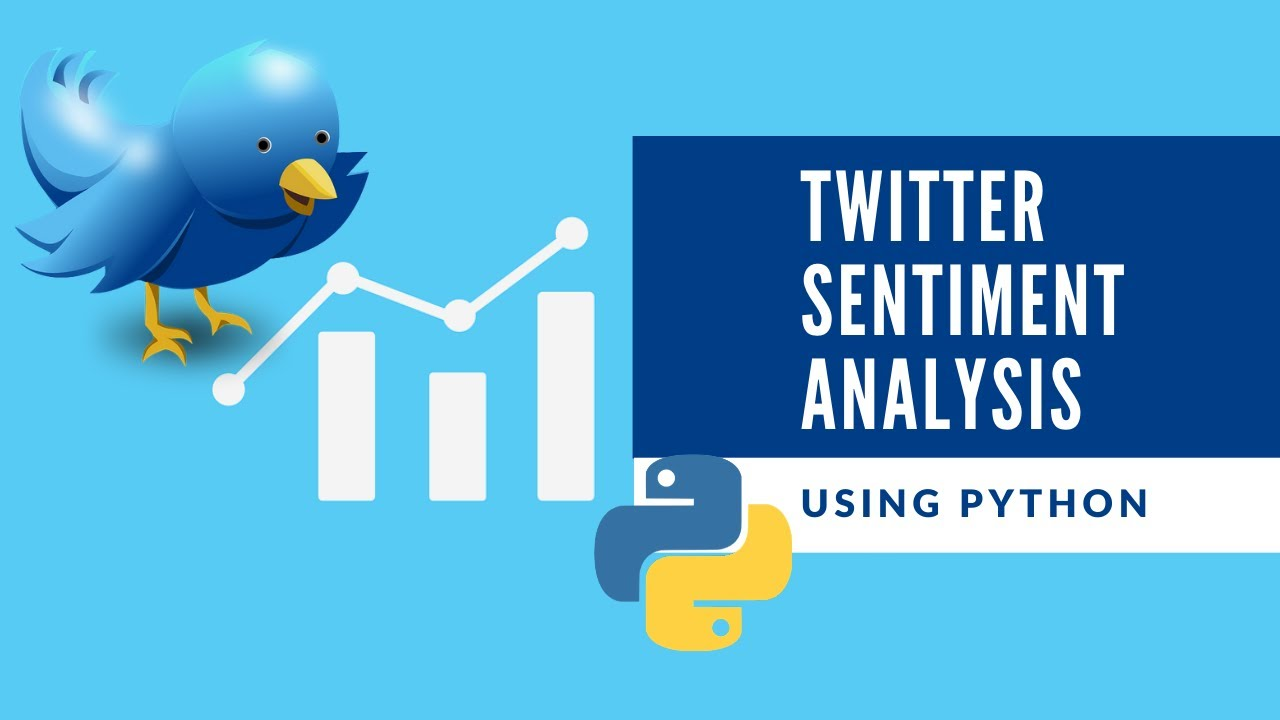

**Scenario**:By analyzing text data, we can find meaningful insights from non-numeric data that can help us achieve our objective.With the help of NLP and its concepts,we can do it.Twitterisone of the biggest platforms that people use to write their messages, express their feelings about a particular topic,and share knowledge in the form oftext. By analyzingtext data,we can make good decisions for different use cases like judging the sentiment of the human tweets, and anyproduct review/comments can tell us the performance of a product in the market.NLP allows us to study and understand the colinearity of the data.So we canpredict our objective

**Objective:** Use Python libraries such as Pandas for data operations and EDA tasks,NLTK to extract and analyze the information,Sklearn for model building and performance visualization, to predict our different categories of people’s mindsets.

**Dataset description:**The data contain information about manyTweets in the form oftext and their types,as mentionedbelow.Tweets: Data is in the form ofa sentence written by individuals.category:  Numeric(0: Neutral, -1: Negative, 1: Positive)(It is our dependent variable)

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import nltk

import re
import string
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
#Read the Data from the Given excel file.
df = pd.read_csv('Twitter_Data.csv')

In [ ]:
df.shape

(162980, 2)

In [ ]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
#total unique count otf thre dependent varibles
df.category.value_counts()

 1.0    72250
 0.0    55213
-1.0    35510
Name: category, dtype: int64

In [ ]:
#•Change our dependent variable to categorical. (0 to “Neutral,”-1 to “Negative”, 1 to “Positive”)
df['category']=df['category'].map({-1.0:'Negative', 0.0:'Neutral', 1.0:'Positive'})

In [ ]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,Negative
1,talk all the nonsense and continue all the dra...,Neutral
2,what did just say vote for modi welcome bjp t...,Positive
3,asking his supporters prefix chowkidar their n...,Positive
4,answer who among these the most powerful world...,Positive


In [ ]:
#•Do Missing value analysisand drop all null/missing values
df = df.dropna()
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,Negative
1,talk all the nonsense and continue all the dra...,Neutral
2,what did just say vote for modi welcome bjp t...,Positive
3,asking his supporters prefix chowkidar their n...,Positive
4,answer who among these the most powerful world...,Positive


In [ ]:
df.isna().sum()

clean_text    0
category      0
dtype: int64

In [ ]:
punch = string.punctuation
punch

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
stopwords = stopwords.words('english')
stopwords


In [ ]:
ps = nltk.PorterStemmer()
wn = nltk.WordNetLemmatizer()


In [ ]:
def cleanData(text):

    # To convert the all uppercase to lowercase
    text = text.lower()

    # This is a reguglar expression to replace anything char that is not alphabet or numeric.
    text = re.sub(r"[^A-Za-z0-9]",' ', text)

    # The above regular expression itself will take care of punctuation, below is an alternative to remove only punctuation.
    text = ''.join([char for char in text if char not in punch])

    # This will remove the stopwords and lemmatize the remaining word to its root word.
    text = [wn.lemmatize(word) for word in text.split(' ') if ((word not in stopwords) & len(word)!=0)]

    return ' '.join(text)

In [ ]:

df['Tweet'] = df['clean_text'].apply(lambda x:cleanData(x))

In [ ]:
df.head()

,clean_text,category,Tweet
0,when modi promised “minimum government maximum...,Negative,minimum maximum begin difficult job reforming ...
1,talk all the nonsense and continue all the dra...,Neutral,drama
2,what did just say vote for modi welcome bjp t...,Positive,say welcome bjp rahul think relax
3,asking his supporters prefix chowkidar their n...,Positive,chowkidar name great service confusion crustal...
4,answer who among these the most powerful world...,Positive,among world today trump putin may


In [ ]:
df['Tweet'][0]

'minimum maximum begin difficult job reforming state year get justice state temple'

In [ ]:
def word_lenght(text):
  return len(text.split())

In [ ]:
df['word length'] = [word_lenght(text) for text in df['Tweet']]

In [ ]:
df.head()

,clean_text,category,Tweet,word length
0,when modi promised “minimum government maximum...,Negative,minimum maximum begin difficult job reforming ...,12
1,talk all the nonsense and continue all the dra...,Neutral,drama,1
2,what did just say vote for modi welcome bjp t...,Positive,say welcome bjp rahul think relax,6
3,asking his supporters prefix chowkidar their n...,Positive,chowkidar name great service confusion crustal...,10
4,answer who among these the most powerful world...,Positive,among world today trump putin may,6


In [ ]:
#Split data into dependent(X) and independent(y) dataframe
X = df[['clean_text','Tweet']]
X.head()

,clean_text,Tweet
0,when modi promised “minimum government maximum...,minimum maximum begin difficult job reforming ...
1,talk all the nonsense and continue all the dra...,drama
2,what did just say vote for modi welcome bjp t...,say welcome bjp rahul think relax
3,asking his supporters prefix chowkidar their n...,chowkidar name great service confusion crustal...
4,answer who among these the most powerful world...,among world today trump putin may


In [ ]:
y=df['category']
y.head()

0    Negative
1     Neutral
2    Positive
3    Positive
4    Positive
Name: category, dtype: object

In [ ]:
message = X.copy()

In [ ]:
message.reset_index(inplace=True)

In [ ]:
### Data Preprocessing
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []
for i in range(0, len(message)):
    print(i)
    review = re.sub('[^a-zA-Z]', ' ', message['Tweet'][i])
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review if ((word not in stopwords) & len(word)!=0)]
    review = ' '.join(review)
    corpus.append(review)

In [ ]:
#Do one-hot encoding for each sentence(use TensorFlow)
from tensorflow.keras.preprocessing.text import one_hot
voc_size = 5000
onehot_repr = [one_hot(w,voc_size)for w in corpus]
onehot_repr

In [ ]:
#Add padding from the front side (use Tensorflow)
from tensorflow.keras.preprocessing.sequence import pad_sequences
sent_lenght = 20
embeded = pad_sequences(onehot_repr,padding='pre',maxlen=sent_lenght)
print(embeded)

[[   0    0    0 ... 2031 4688 4048]
 [   0    0    0 ...    0    0   57]
 [   0    0    0 ... 4500 2401 1068]
 ...
 [   0    0    0 ...   69  379  765]
 [   0    0    0 ... 4081 2587 3158]
 [   0    0    0 ...  953 3066 3494]]


In [ ]:
embeded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0, 1309,
        550, 1337, 1375, 3362, 1489, 4048, 2031, 4688, 4048], dtype=int32)

In [ ]:
#Build anLSTM model and compile it(describe features, input length, vocabulary size, information drop-out layer, activation function for output, )
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Bidirectional,Dropout

In [ ]:
#creating a model
embedding_vector_features=40
model1=Sequential()
model1.add(Embedding(voc_size,embedding_vector_features,input_length=20))
model1.add(Bidirectional(LSTM(100)))
model1.add(Dropout(0.3))
model1.add(Dense(3,activation='softmax'))
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(model1.summary())


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 20, 40)            200000    
                                                                 
 bidirectional (Bidirectiona  (None, 200)              112800    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 200)               0         
                                                                 
 dense (Dense)               (None, 3)                 603       
                                                                 
Total params: 313,403
Trainable params: 313,403
Non-trainable params: 0
_________________________________________________________________
None


In [ ]:
len(embeded),y.shape

(162969, (162969,))

In [ ]:
X_final = np.array(embeded)
y_final = np.array(y)

In [ ]:
X_final.shape,y_final.shape

((162969, 20), (162969,))

In [ ]:
y.head()

0    Negative
1     Neutral
2    Positive
3    Positive
4    Positive
Name: category, dtype: object

In [ ]:
y_final = pd.get_dummies(y_final)
y_final.head()

,Negative,Neutral,Positive
0,1,0,0
1,0,1,0
2,0,0,1
3,0,0,1
4,0,0,1


In [ ]:
#split the data into tests and train
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_final,y_final,test_size=0.2,random_state=42)

In [ ]:
#Train new model
model1.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
2038/2038 [==============================] - 137s 65ms/step - loss: 0.4961 - accuracy: 0.6211 - val_loss: 0.4760 - val_accuracy: 0.6410
Epoch 2/10
2038/2038 [==============================] - 131s 64ms/step - loss: 0.4659 - accuracy: 0.6560 - val_loss: 0.4756 - val_accuracy: 0.6404
Epoch 3/10
2038/2038 [==============================] - 131s 64ms/step - loss: 0.4570 - accuracy: 0.6655 - val_loss: 0.4766 - val_accuracy: 0.6411
Epoch 4/10
2038/2038 [==============================] - 133s 65ms/step - loss: 0.4464 - accuracy: 0.6746 - val_loss: 0.4784 - val_accuracy: 0.6418
Epoch 5/10
2038/2038 [==============================] - 129s 63ms/step - loss: 0.4349 - accuracy: 0.6855 - val_loss: 0.4818 - val_accuracy: 0.6390
Epoch 6/10
2038/2038 [==============================] - 130s 64ms/step - loss: 0.4236 - accuracy: 0.6952 - val_loss: 0.4921 - val_accuracy: 0.6390
Epoch 7/10
2038/2038 [==============================] - 130s 64ms/step - loss: 0.4122 - accuracy: 0.7046 - val_loss: 0

In [ ]:
y_pred1 = model1.predict(X_test)


1019/1019 [==============================] - 10s 9ms/step


In [ ]:
y_pred1[0]

array([0.05453953, 0.5066944 , 0.43876615], dtype=float32)

In [ ]:
y_pred1[0:10]


array([[5.4539531e-02, 5.0669438e-01, 4.3876615e-01],
       [3.7220987e-03, 9.8783147e-01, 8.4463246e-03],
       [5.1391047e-01, 1.7184971e-02, 4.6890453e-01],
       [9.9798936e-01, 1.3368360e-04, 1.8768096e-03],
       [3.0884647e-01, 3.2719374e-01, 3.6395979e-01],
       [9.9300951e-02, 6.2319362e-01, 2.7750543e-01],
       [2.1081221e-01, 5.1314896e-01, 2.7603868e-01],
       [3.1521481e-01, 2.2423732e-01, 4.6054780e-01],
       [8.7364388e-01, 4.1365869e-02, 8.4990270e-02],
       [8.5588813e-02, 9.4260657e-03, 9.0498513e-01]], dtype=float32)

In [ ]:
ex=y_pred1.copy()
ex[1]


array([0.0037221 , 0.9878315 , 0.00844632], dtype=float32)

In [ ]:
#Normalize the prediction as same as orignal data
count  = 0
for i in range(len(ex)):
  if (ex[i][0] >ex[i][1] and ex[i][0] >ex[i][2]):
    count =0

  elif(ex[i][0] <ex[i][1] and ex[i][0] >ex[i][2]):
    count =1

  elif(ex[i][0] <ex[i][1] and ex[i][0] <ex[i][2]):
    count=2

  print (i,"for count is",count)
  for j in range(3):
    ex[i][j]=0
    ex[i][count] =1
  print(ex[i])
  count = 0


In [ ]:
#Measure performance metrics and accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,ex)

0.34119776646008465

In [ ]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,ex))


              precision    recall  f1-score   support

           0       0.32      0.61      0.42      7152
           1       0.52      0.08      0.14     11067
           2       0.34      0.41      0.37     14375

   micro avg       0.34      0.34      0.34     32594
   macro avg       0.39      0.37      0.31     32594
weighted avg       0.40      0.34      0.30     32594
 samples avg       0.34      0.34      0.34     32594

